# Comparativa: CrewAI vs LangGraph

**Objetivo de esta entrega**: mostrar, para el mismo sistema multi-agente de accesibilidad, cómo se **cruza la información entre agentes** en cada framework, y una primera **comparación cuantitativa de ruteo** usando `dataset.csv`.

## 0. Configuración e imports

In [1]:
import os, sys, json, time, inspect
from pathlib import Path
import importlib.util

os.environ.setdefault("CREWAI_TRACING_ENABLED", "false")  # menos ruido en consola

# Las carpetas de este repo se llaman IGUAL que las librerías pip (crewai/,
# langgraph/). Si la raíz del repo entra a sys.path, puede ensombrecerlas. Por
# eso importamos primero las LIBRERÍAS pip: quedan cacheadas en sys.modules y
# las importaciones internas de nuestro código las resuelven desde la caché.
import crewai            # noqa: F401  (librería)
import crewai.tools      # noqa: F401
import langgraph         # noqa: F401  (librería)
import langgraph.graph   # noqa: F401
import langchain_openai  # noqa: F401

# Raíz del repo (este notebook vive en notebooks/).
RAIZ = Path.cwd()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent
print("Raíz del repo:", RAIZ)

# Si el kernel ya tenía cargados los módulos de ESTE repo de una corrida
# anterior, los purgamos para que se re-lean del disco con el código actual.
# Evita el clásico "editaste el .py pero el kernel sigue usando la versión
# vieja" (p. ej. un model id que ya cambiaste). No toca las librerías pip.
for _m in [x for x in list(sys.modules)
           if x in ("crewai_agentes", "grafo", "agentes", "estado") or x.startswith("rag")]:
    del sys.modules[_m]

def _cargar(nombre, ruta):
    """Carga un .py bajo un nombre de módulo explícito (evita el choque entre
    el 'agentes' de crewai/ y el de langgraph/)."""
    spec = importlib.util.spec_from_file_location(nombre, ruta)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[nombre] = mod
    spec.loader.exec_module(mod)
    return mod

# CrewAI de este repo, con nombre único.
crew = _cargar("crewai_agentes", RAIZ / "crewai" / "agentes.py")

# LangGraph de este repo: grafo.py hace 'from agentes/estado import ...', que se
# resuelven con langgraph/ en sys.path. 'agentes' aquí es el de LangGraph (el de
# CrewAI se cargó como 'crewai_agentes').
sys.path.insert(0, str(RAIZ))
sys.path.insert(0, str(RAIZ / "langgraph"))
import grafo as lg
import agentes as lg_ag   # para acceder a DecisionIntencion (Pydantic)

print("CrewAI y LangGraph cargados. Modelo:", crew.VLLM_CHAT_MODEL)

Raíz del repo: /home/mpillapa/Tesis_Manuel/accessibility-agents
CrewAI y LangGraph cargados. Modelo: google/gemma-4-12B-it


## 1. Cruce de información entre agentes (una frase)

Se toma una frase y se observa qué se pasan los agentes en cada framework.

In [14]:
FRASE = "Que sabes a dia de de de recetas para diabeticos tipo 1 en edades de 7 y 12 años"

### 1a. LangGraph — estado compartido, visible nodo por nodo

`traza_por_nodo()` usa `app.stream(..., stream_mode="updates")`: cada elemento es *lo que ese nodo escribió en el estado compartido*. No hay mensajes directos entre agentes — hay un único objeto de estado que cada nodo lee y sobre el que escribe. Esto es exactamente "la información que se cruza entre los agentes".

In [15]:
try:
    traza = lg.traza_por_nodo(FRASE)
    print(f"Consulta: {FRASE!r}\n")
    print("Cruce de información en LangGraph (qué escribió cada nodo en el estado):\n")
    for paso in traza:
        print(f"[NODO: {paso['nodo']}] escribió:")
        print(json.dumps(paso["cambios"], ensure_ascii=False, indent=2))
        print()
except Exception as e:
    print("No se pudo ejecutar (¿VPN institucional activa?). Detalle:", repr(e))

Consulta: 'Que sabes a dia de de de recetas para diabeticos tipo 1 en edades de 7 y 12 años'

Cruce de información en LangGraph (qué escribió cada nodo en el estado):

[NODO: orchestrator] escribió:
{
  "intencion": "RECIPE_MULTIMEDIA",
  "razonamiento": "La persona busca orientación nutricional y opciones de alimentación específicas para niños con diabetes tipo 1."
}

[NODO: recetas] escribió:
{
  "respuesta": "Hola, es un gusto saludarle. Entiendo perfectamente su consulta sobre opciones para niños con diabetes tipo 1.\n\nSin embargo, debo informarle que **no cuento con recetas para diabéticos en mi recetario actual**. La receta que tengo disponible es para un postre de arroz con leche, el cual contiene azúcar y leche, por lo que no sería adecuado para esa condición específica.\n\nComo su asistente culinario, mi función es guiarle paso a paso con las recetas que tengo a mano, adaptando las medidas para que sean fáciles de seguir. Si desea preparar el arroz con leche para otra ocasión

#### La decisión del Orchestrator como formato estructurado (Pydantic → JSON)

El Orchestrator no devuelve texto suelto: su decisión se valida con el modelo Pydantic `DecisionIntencion` y puede serializarse a JSON. Este es el "formato estructurado de respuesta" del artículo que enviaron los tutores. (Ver `langgraph/README.md`: contra este servidor el JSON *forzado* falló, así que se genera en texto y Pydantic **valida** el resultado.)

In [5]:
try:
    orch = next(p["cambios"] for p in traza if p["nodo"] == "orchestrator")
    decision = lg_ag.DecisionIntencion(intencion=orch["intencion"], razonamiento=orch["razonamiento"])
    print("DecisionIntencion (validada por Pydantic) serializada a JSON:\n")
    print(decision.model_dump_json(indent=2))
except Exception as e:
    print("No disponible (corre antes la celda anterior con VPN). Detalle:", repr(e))

DecisionIntencion (validada por Pydantic) serializada a JSON:

{
  "razonamiento": "El usuario busca una sugerencia de cocina sencilla y de preparación veloz para su alimentación diaria.",
  "intencion": "RECIPE_MULTIMEDIA"
}


### 1b. CrewAI — delegación

En CrewAI el Orchestrator (`allow_delegation=True`) decide y **delega** al especialista mediante el tool calling interno del framework. El cruce no es un estado inspeccionable sino una llamada de delegación. La respuesta final incluye una línea `AGENTE: <rol>` que revela quién contestó.

Se usa `procesar_consulta_async` con `await`: dentro de Jupyter ya hay un event loop y CrewAI exige `kickoff_async` (la versión síncrona `crew.procesar_consulta()` es para scripts). Para ver la delegación paso a paso en vivo: `python crewai/demo.py "<frase>"` (corre con `verbose=True`).

In [6]:
try:
    res = await crew.procesar_consulta_async(FRASE)
    print(f"Consulta: {FRASE!r}\n")
    print("Respuesta final de la crew (el Orchestrator delegó internamente):\n")
    print(res["respuesta"])
    print(f"\nLatencia: {res['latencia_segundos']}s")
except Exception as e:
    print("No se pudo ejecutar (¿VPN institucional activa?). Detalle:", repr(e))

Consulta: 'te sabes alguna receta para hacer rapido'

Respuesta final de la crew (el Orchestrator delegó internamente):

AGENTE: Especialista en Recetas y Multimedia

¡Claro que sí! Con mucho gusto le ayudo. He seleccionado una receta de una sopa de verduras muy sencilla, nutritiva y que se prepara rápidamente. Es ideal porque no requiere técnicas complicadas y los ingredientes son muy comunes.

Aquí tiene los pasos detallados para que la prepare sin complicaciones:

### **Sopa de Verduras Reconfortante**

**Lo que va a necesitar (Ingredientes):**
*   **2 zanahorias** (puedes pedirle a alguien que las pique o cortarlas en rodajas finitas).
*   **1 papa grande** (cortada en cubos pequeños).
*   **Media taza de arvejas** (unas 10 o 12 arvejas si son frescas, o un puñadito si son de lata).
*   **1 rama de apio** (picadita).
*   **Caldo de pollo o agua:** Necesitará aproximadamente **1 litro y medio** (esto es como **6 vasos grandes** de agua o caldo).
*   **Sal** al gusto.

---

**Pasos p

### La diferencia, en una tabla

| | CrewAI | LangGraph |
|---|---|---|
| Mecanismo de ruteo | Delegación (tool calling interno) | Edge condicional sobre `intencion` |
| Cómo viaja la info | El framework la gestiona internamente | Estado compartido (`EstadoConversacion`) explícito |
| ¿Se puede inspeccionar el cruce? | Con `verbose=True` (traza en consola) | Sí, como datos: `stream()` entrega el delta por nodo |
| Formato estructurado | El `expected_output` del `Task` | Pydantic `DecisionIntencion` validado |

Misma arquitectura de agentes y mismo LLM (`gemma-4-31B`) en ambos, para que la comparación no mezcle variables.

## 2. Accuracy de ruteo con `dataset.csv`

`dataset.csv` tiene 415 frases etiquetadas (83 por intención) en español coloquial ecuatoriano — las mismas 5 intenciones que rutea el sistema. Medimos la decisión de clasificación del Orchestrator de cada framework contra la etiqueta real.

`clasificar_consulta()` corre **solo** la decisión del Orchestrator (una llamada al LLM), no la delegación + respuesta completa, para que la comparación sea directa y rápida.

> **Nota metodológica**: ambos frameworks delegan la decisión al mismo modelo, así que se espera una accuracy parecida. Lo que realmente diferencia a CrewAI de LangGraph es el *mecanismo* de ruteo, la latencia y lo explícito del flujo de datos — no la calidad de clasificación en sí.

In [7]:
import pandas as pd

df = pd.read_csv(RAIZ / "dataset.csv")
print("Total de frases:", len(df))
print(df["intent"].value_counts(), "\n")

# Cada frase = 1 llamada al LLM por framework. Se evalúa una muestra estratificada
# para que corra en tiempo razonable. Súbelo para más cobertura (más lento / más tokens).
MUESTRA_POR_INTENCION = 10
muestra = df.groupby("intent", group_keys=False).head(MUESTRA_POR_INTENCION).reset_index(drop=True)

print(f"Evaluando {len(muestra)} de {len(df)} frases "
      f"({MUESTRA_POR_INTENCION} por intención).")
print("Ajusta MUESTRA_POR_INTENCION para cambiar la cobertura.")

Total de frases: 415
intent
MEDICATION_HEALTH       83
FAMILY_COMMUNICATION    83
EMERGENCY               83
SMALL_TALK              83
RECIPE_MULTIMEDIA       83
Name: count, dtype: int64 

Evaluando 50 de 415 frases (10 por intención).
Ajusta MUESTRA_POR_INTENCION para cambiar la cobertura.


In [11]:
# evaluar() es async: el clasificador de CrewAI es una corrutina (kickoff_async,
# obligatorio en Jupyter); el de LangGraph es síncrono. inspect.isawaitable
# permite usar la misma función para ambos.
async def evaluar(clasificador, frases, nombre):
    filas = []
    print(f"{nombre} (requiere VPN)...")
    for i, (_, fila) in enumerate(frases.iterrows(), 1):
        t0 = time.time()
        try:
            pred = clasificador(fila["text"])
            if inspect.isawaitable(pred):
                pred = await pred
        except Exception as e:
            pred = f"ERROR:{type(e).__name__}"
        filas.append({
            "text": fila["text"],
            "real": fila["intent"],
            "pred": pred,
            "latencia_s": round(time.time() - t0, 2),
        })
        print(f"  {i}/{len(frases)}", end="\r")
    print()
    return pd.DataFrame(filas)

res_crew = await evaluar(crew.clasificar_consulta_async, muestra, "CrewAI")
res_lg = await evaluar(lg.clasificar_consulta, muestra, "LangGraph")

CrewAI (requiere VPN)...


  50/50
LangGraph (requiere VPN)...


ERROR:opentelemetry.exporter.otlp.proto.http.trace_exporter:Failed to export span batch due to timeout, max retries or shutdown.


  50/50


Resultados de ruteo:

CrewAI     accuracy=100.0%  latencia_media= 0.28s  (evaluadas 50/50)
LangGraph  accuracy=100.0%  latencia_media= 0.20s  (evaluadas 50/50)


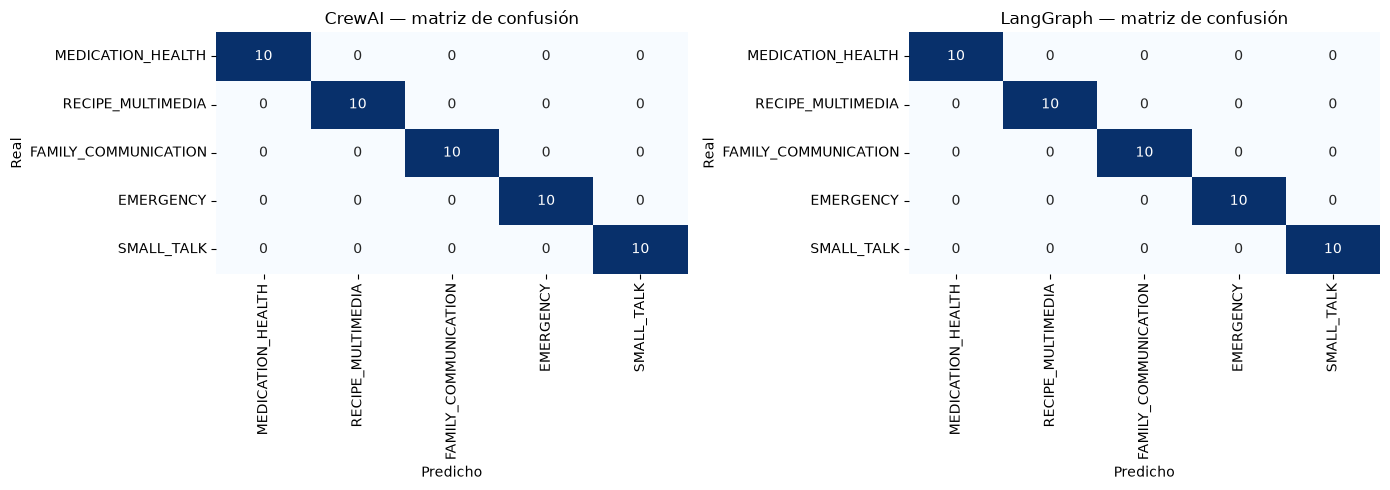

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

def resumen(nombre, res):
    validos = res[~res["pred"].str.startswith("ERROR")]
    acc = (validos["real"] == validos["pred"]).mean() if len(validos) else float("nan")
    lat = validos["latencia_s"].mean() if len(validos) else float("nan")
    print(f"{nombre:10s} accuracy={acc:6.1%}  latencia_media={lat:5.2f}s  "
          f"(evaluadas {len(validos)}/{len(res)})")
    return acc

print("Resultados de ruteo:\n")
resumen("CrewAI", res_crew)
resumen("LangGraph", res_lg)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (nombre, res) in zip(axes, [("CrewAI", res_crew), ("LangGraph", res_lg)]):
    v = res[~res["pred"].str.startswith("ERROR")]
    if len(v):
        cm = pd.crosstab(v["real"], v["pred"]).reindex(
            index=crew.INTENCIONES, columns=crew.INTENCIONES, fill_value=0)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(f"{nombre} — matriz de confusión")
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

## 3. Interpretación, limitaciones y pendientes

**Qué muestra este notebook**
- El cruce de información entre agentes en ambos frameworks: estado compartido inspeccionable (LangGraph) vs delegación (CrewAI).
- La decisión del Orchestrator como objeto Pydantic serializable a JSON.
- Una primera métrica cuantitativa de ruteo (accuracy + matriz de confusión) sobre una muestra de `dataset.csv`.

**Limitaciones / supuestos**
- **No ejecutado aquí**: requiere VPN institucional; falta correrlo y pegar resultados reales.
- **Muestra, no dataset completo**: por defecto 10 frases por intención (50 de 415). El conteo evaluado se imprime explícitamente; subir `MUESTRA_POR_INTENCION` para cobertura total.
- **La accuracy mide la clasificación del Orchestrator**, no la delegación completa de CrewAI. Como ambos usan el mismo LLM, se espera accuracy similar; el valor de la comparación está en mecanismo, latencia y legibilidad.
- `dataset.csv` es una base **simulada** (frases sintéticas etiquetadas), no datos productivos.

**Pendiente**
- Correr con VPN y registrar accuracy/latencia reales de cada framework.
- Cerrar la comparación con líneas de código y legibilidad del flujo de datos (ver `langgraph/README.md`).
- Repetir con `gemma-4-31B` el hallazgo de salida estructurada de Pydantic documentado con `llama3.1:8b`.